In [18]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

Results directory: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


# All vs Cost vs Separation

Compare three tracking strategies against ground truth:

- track all particles with a distance-only peak-linking cost
- track all particles with the enhanced peak-linking cost selected in `CostExperiment`
- track a conservative static subset first, remove those peaks, then track the remaining particles with distance-only costs

The summary is restricted to coverage, mean position error, and number of tracks found.

In [19]:
from pathlib import Path
import os
import sys

import importlib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import Experiments.all_vs_cost_vs_sep_experiment as avcvs
importlib.reload(avcvs)
from Experiments.all_vs_cost_vs_sep_experiment import *

pd.set_option("display.max_colwidth", 120)
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


## Regular Simulation

These parameters are read from the module, so any hand-edited regular-simulator values stay centralized there.

In [20]:
display(configuration_table())
display(cost_table())

,group,parameter,value
0,simulation,nparticles,20
1,simulation,nframes,100
2,simulation,nposframe,10
3,simulation,D_list,"[(0.02, 0.16), (0.08, 0.14), (0.25, 0.14), (0.75, 0.14), (2.0, 0.14), (4.5, 0.14), (8.0, 0.14)]"
4,simulation,dt,1.0
5,simulation,anisotropy_ratio_range,"(0.75, 1.0)"
6,simulation,theta_range,"(0, 3.141592653589793)"
7,simulation,frame_size,"(128, 128)"
8,simulation,intensity_mean,600
9,simulation,intensity_std,150


,role,name,distance,intensity,sigma,position,length,start_frame
0,all/separated distance peak cost,distance_only,1.0,0.0,0.0,NaN,NaN,NaN
1,all enhanced peak cost,dist_meta_50_40_10,0.6,0.4,0.0,NaN,NaN,NaN
2,shared GT assignment/evaluation cost,pos_len_75_25,NaN,NaN,NaN,0.75,0.25,0.0


In [21]:
import Experiments.all_vs_cost_vs_sep_experiment as avcvs
importlib.reload(avcvs)
from Experiments.all_vs_cost_vs_sep_experiment import *

results_df, summary_df = run_experiment(
    seeds=SEEDS,
    force_rerun=True,
    verbose=True,
)

display(results_df[display_columns()].round(3))
display(summary_df.round(3))

print(f"Saved per-seed results to {RESULTS_PATH}")
print(f"Saved summary to {SUMMARY_PATH}")

Tracking 1720 peaks across 100 frames...
Tracking 1720 peaks across 100 frames...
Tracking 1720 peaks across 100 frames...
Tracking 1249 peaks across 100 frames...
seed=0: done in 151.05s
Tracking 1876 peaks across 100 frames...
Tracking 1876 peaks across 100 frames...
Tracking 1876 peaks across 100 frames...
Tracking 965 peaks across 100 frames...
seed=1: done in 158.39s
Tracking 1932 peaks across 100 frames...
Tracking 1932 peaks across 100 frames...
Tracking 1932 peaks across 100 frames...
Tracking 1373 peaks across 100 frames...
seed=2: done in 138.43s


,seed,method,gt_count,coverage_pct,mean_error_px,n_tracks
0,0,all_distance,20,38.10,1.507,75
1,0,all_enhanced,20,46.75,0.976,62
2,0,separated_distance,20,37.05,1.429,79
3,1,all_distance,20,58.10,1.132,57
4,1,all_enhanced,20,55.90,1.157,63
5,1,separated_distance,20,46.75,0.955,74
6,2,all_distance,20,52.00,1.060,73
7,2,all_enhanced,20,54.35,1.258,67
8,2,separated_distance,20,45.60,1.235,77


,method,method_label,n,coverage_pct_mean,coverage_pct_ci95,mean_error_px_mean,mean_error_px_ci95,n_tracks_mean,n_tracks_ci95
0,all_distance,All - distance,3,49.400,11.599,1.233,0.271,68.333,11.164
1,all_enhanced,All - enhanced cost,3,52.333,5.542,1.130,0.162,64.000,2.994
2,separated_distance,Separated - distance,3,43.133,5.997,1.207,0.270,76.667,2.848


Saved per-seed results to C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_results.csv
Saved summary to C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_summary.csv


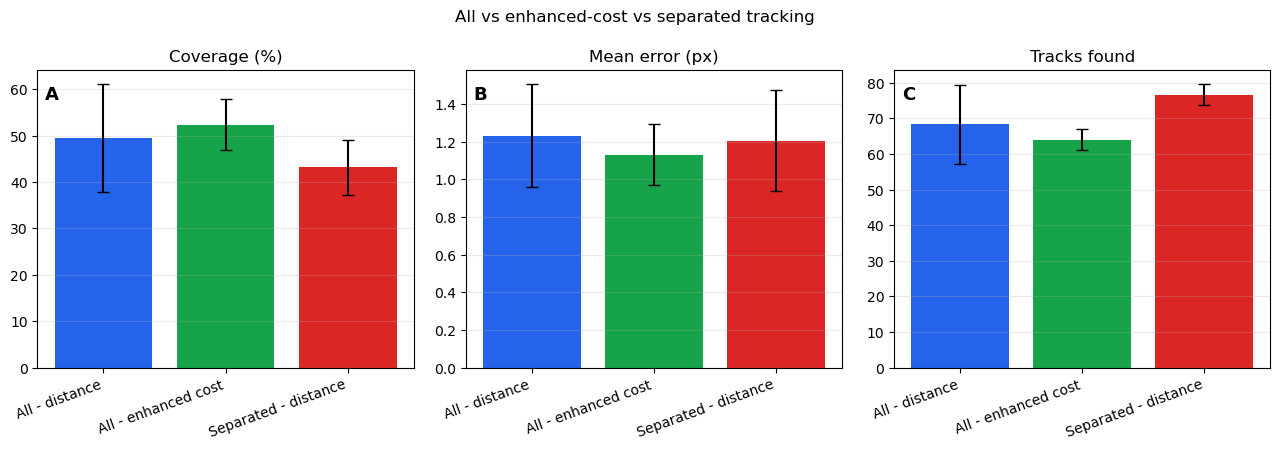

Saved figure to C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_summary.png


In [22]:
fig = plot_summary(summary_df)
plt.show()
print(f"Saved figure to {FIGURE_PATH}")

In [26]:
from Helpers.helpersPlotting import *

In [30]:
def plot_coverage_error_tradeoff(summary_df, save_path=None):
    """
    Scatter/bubble plot:
    x = mean error,
    y = coverage
    """
    colors = ["#2563eb", "#16a34a", "#dc2626"]
    labels = summary_df["method_label"].tolist()

    x = summary_df["mean_error_px_mean"].to_numpy(dtype=float)
    y = summary_df["coverage_pct_mean"].to_numpy(dtype=float)
    n_tracks = summary_df["n_tracks_mean"].to_numpy(dtype=float)

    xerr = np.nan_to_num(summary_df["mean_error_px_ci95"].to_numpy(dtype=float), nan=0.0)
    yerr = np.nan_to_num(summary_df["coverage_pct_ci95"].to_numpy(dtype=float), nan=0.0)

    sizes = np.full_like(n_tracks, 200.0)

    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    for i, label in enumerate(labels):
        ax.errorbar(
            x[i],
            y[i],
            xerr=xerr[i],
            yerr=yerr[i],
            fmt="none",
            ecolor="black",
            elinewidth=1,
            capsize=3,
            alpha=0.6,
            zorder=1,
        )

        ax.scatter(
            x[i],
            y[i],
            s=sizes[i],
            color=colors[i % len(colors)],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.8,
            label=f"{label} (tracks={n_tracks[i]:.1f})",
            zorder=2,
        )

        ax.annotate(
            label,
            (x[i], y[i]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
        )

    ax.set_xlabel("Mean localization error (px)")
    ax.set_ylabel("Coverage (%)")
    ax.set_title("Coverage-error trade-off")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, loc="best")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig

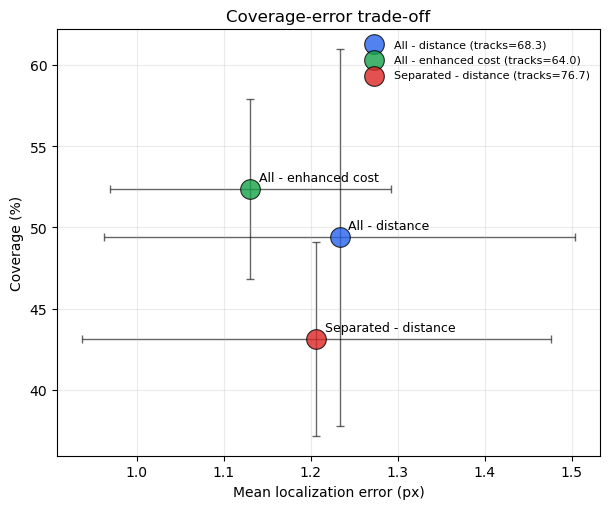

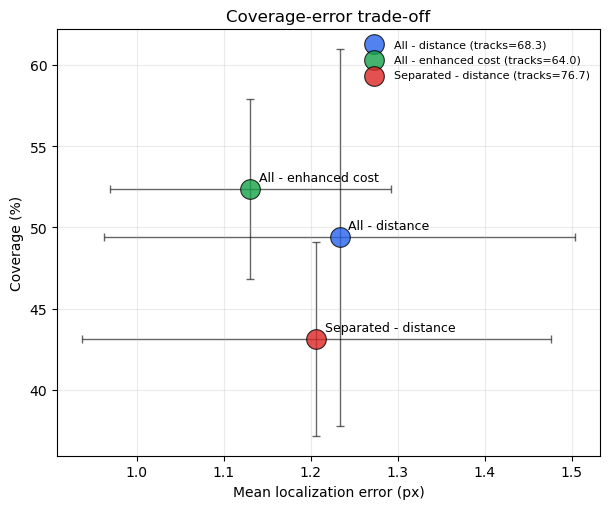

In [31]:
plot_coverage_error_tradeoff(summary_df, save_path=OUT_DIR / "coverage_error_tradeoff.png")

In [35]:
import importlib
import Experiments.all_vs_cost_vs_sep_experiment as exp

importlib.reload(exp)

from Experiments.all_vs_cost_vs_sep_experiment import (
    RESULTS_PATH,
    SUMMARY_PATH,
    FIGURE_PATH,
    LR_RESULTS_PATH,
    LR_SUMMARY_PATH,
    LR_FIGURE_PATH,
    run_experiment,
    run_ligand_receptor_experiment,
    summarize_results,
    summarize_ligand_receptor_results,
    plot_mot_summary,
    plot_ligand_receptor_mot_summary,
)

Tracking 1720 peaks across 100 frames...
Tracking 1720 peaks across 100 frames...
Tracking 1720 peaks across 100 frames...
Tracking 1249 peaks across 100 frames...
seed=0: done in 173.37s
Tracking 1876 peaks across 100 frames...
Tracking 1876 peaks across 100 frames...
Tracking 1876 peaks across 100 frames...
Tracking 965 peaks across 100 frames...
seed=1: done in 159.30s

Homogeneous tracking summary:
        method_label  hota_mean  deta_mean  assa_mean  idf1_mean  mota_mean  motp_px_mean  coverage_mean  median_error_px_mean  n_tracks_mean
      All - distance      0.619      0.718      0.535      0.834      0.669         0.809          0.751                 0.650           66.0
 All - enhanced cost      0.643      0.720      0.574      0.836      0.668         0.815          0.755                 0.653           62.5
Separated - distance      0.566      0.716      0.447      0.833      0.663         0.810          0.750                 0.650           76.5


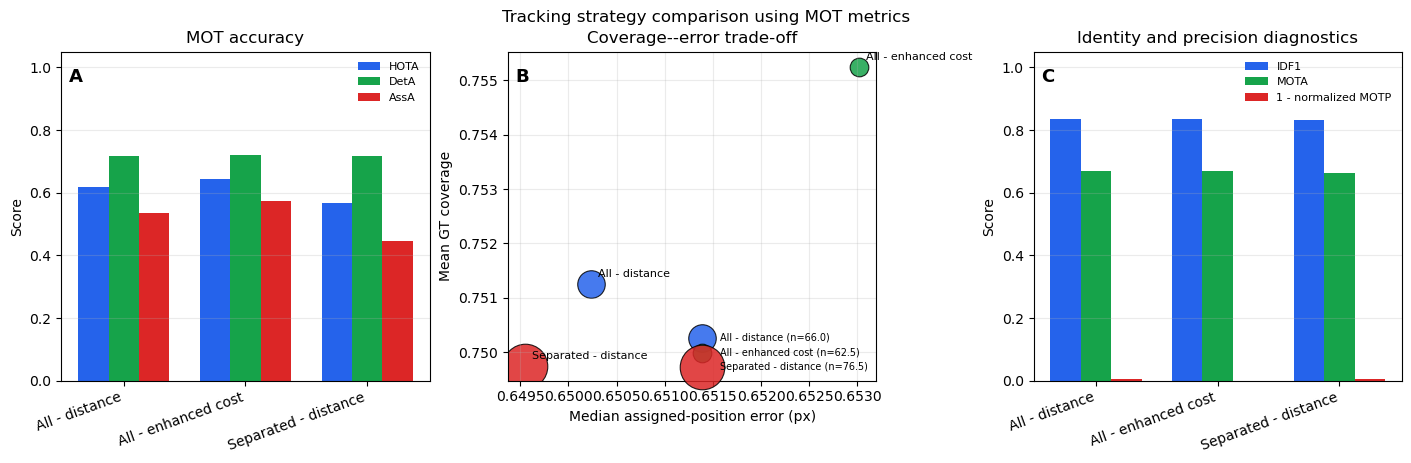

Saved homogeneous figure to: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_hota_summary.png
Tracking 375 peaks across 50 frames...
Tracking 375 peaks across 50 frames...
Tracking 266 peaks across 50 frames...
Tracking 125 peaks across 50 frames...
LR seed=0: done in 54.77s, binding events=14
Tracking 484 peaks across 50 frames...
Tracking 484 peaks across 50 frames...
Tracking 325 peaks across 50 frames...
Tracking 234 peaks across 50 frames...
LR seed=1: done in 53.58s, binding events=8

Ligand--receptor tracking summary:
population         method_label  hota_mean  deta_mean  assa_mean  idf1_mean  mota_mean  motp_px_mean  coverage_mean  median_error_px_mean  n_tracks_mean  binding_events_mean
    ligand       All - distance      0.515      0.345      0.772      0.513      0.064         1.054          0.473                 0.821           18.0                 11.0
    ligand  All - enhanced cost      0.516      0.345      0.773  

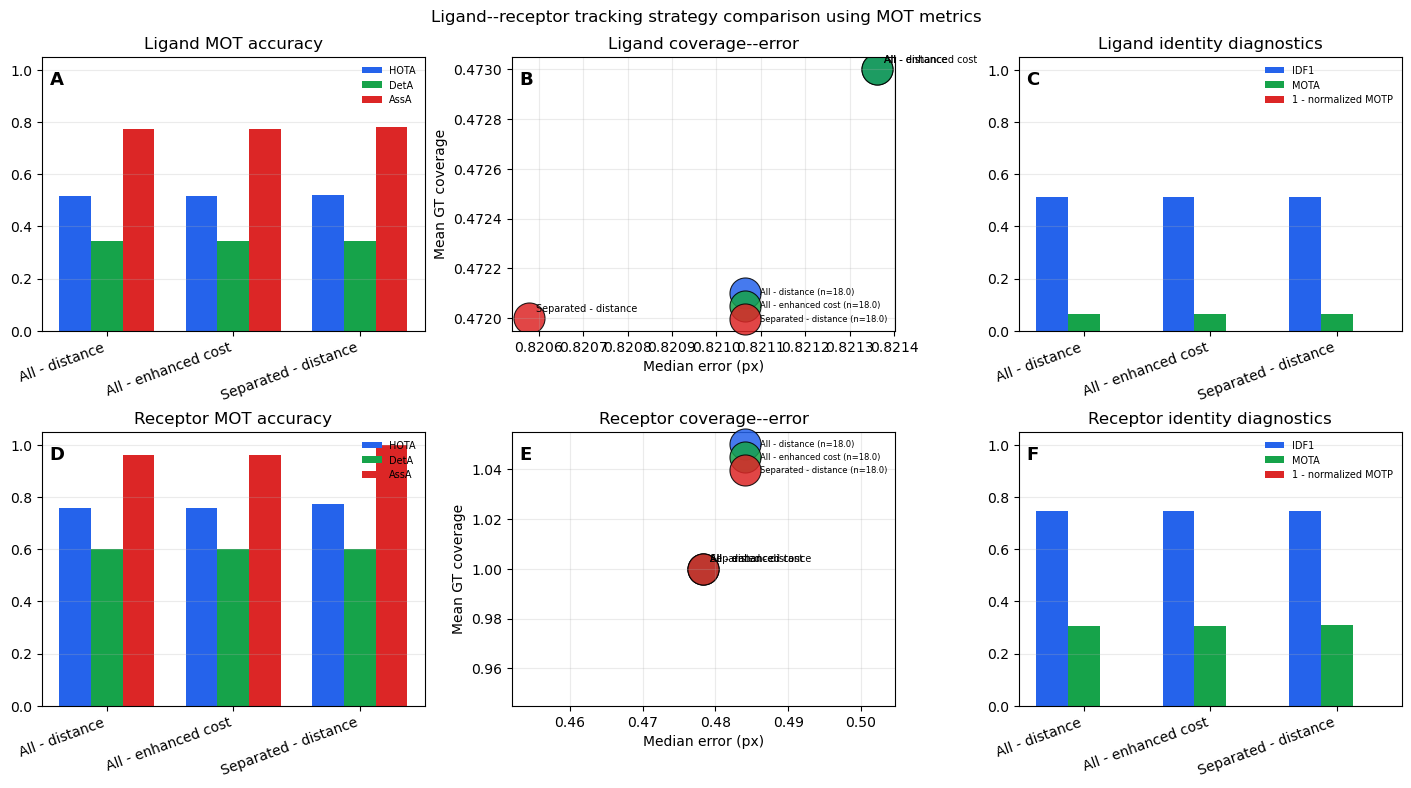

Saved ligand--receptor figure to: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_ligand_receptor_hota_summary.png


In [36]:
from pathlib import Path
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Adjust this filename if you save the helper under another name.
HELPER_NAME = "all_vs_cost_vs_sep_experiment.py"

cwd = Path.cwd().resolve()
helper_path = cwd / "Experiments" / HELPER_NAME

if not helper_path.exists():
    raise FileNotFoundError(
        f"Could not find {HELPER_NAME} in {cwd}. "
        "Place this plotting script in the same folder as the helper file."
    )

sys.path.insert(0, str(cwd))

from Experiments.all_vs_cost_vs_sep_experiment import (  # noqa: E402
    RESULTS_PATH,
    SUMMARY_PATH,
    FIGURE_PATH,
    LR_RESULTS_PATH,
    LR_SUMMARY_PATH,
    LR_FIGURE_PATH,
    run_experiment,
    run_ligand_receptor_experiment,
    summarize_results,
    summarize_ligand_receptor_results,
    plot_mot_summary,
    plot_ligand_receptor_mot_summary,
)


# =============================================================================
# Homogeneous particle experiment
# =============================================================================

force_rerun = False

if force_rerun or not RESULTS_PATH.exists():
    results_df, summary_df = run_experiment(force_rerun=True, verbose=True)
else:
    results_df = pd.read_csv(RESULTS_PATH)
    summary_df = summarize_results(results_df)

summary_df.to_csv(SUMMARY_PATH, index=False)

print("\nHomogeneous tracking summary:")
display_cols = [
    "method_label",
    "hota_mean",
    "deta_mean",
    "assa_mean",
    "idf1_mean",
    "mota_mean",
    "motp_px_mean",
    "coverage_mean",
    "median_error_px_mean",
    "n_tracks_mean",
]
print(summary_df[display_cols].round(3).to_string(index=False))

fig = plot_mot_summary(
    summary_df,
    save_path=FIGURE_PATH,
    title="Tracking strategy comparison using MOT metrics",
)
plt.show()

print(f"Saved homogeneous figure to: {FIGURE_PATH}")


# =============================================================================
# Ligand--receptor experiment
# =============================================================================

if force_rerun or not LR_RESULTS_PATH.exists():
    lr_results_df, lr_summary_df = run_ligand_receptor_experiment(
        force_rerun=True,
        verbose=True,
    )
else:
    lr_results_df = pd.read_csv(LR_RESULTS_PATH)
    lr_summary_df = summarize_ligand_receptor_results(lr_results_df)

lr_summary_df.to_csv(LR_SUMMARY_PATH, index=False)

print("\nLigand--receptor tracking summary:")
display_cols_lr = [
    "population",
    "method_label",
    "hota_mean",
    "deta_mean",
    "assa_mean",
    "idf1_mean",
    "mota_mean",
    "motp_px_mean",
    "coverage_mean",
    "median_error_px_mean",
    "n_tracks_mean",
    "binding_events_mean",
]
print(lr_summary_df[display_cols_lr].round(3).to_string(index=False))

fig = plot_ligand_receptor_mot_summary(
    lr_summary_df,
    save_path=LR_FIGURE_PATH,
)
plt.show()

print(f"Saved ligand--receptor figure to: {LR_FIGURE_PATH}")


## Ligand-Receptor Simulation

This repeats the same three tracking approaches on an interacting ligand-receptor simulation. The simulator keeps `nposframe=10`, uses slow receptors and faster ligands, and produces binding events so the separated pipeline has a meaningful static-receptor masking task.

The same three metrics are reported separately for ligands and receptors.

In [5]:
display(ligand_receptor_configuration_table())
display(cost_table())

,group,parameter,value
0,simulation,n_ligands,10
1,simulation,n_receptors,5
2,simulation,nframes,50
3,simulation,nposframe,10
4,simulation,dt,1.0
5,simulation,ligand_D,"[(3.5, 0.35), (5.0, 0.45), (7.0, 0.2)]"
6,simulation,receptor_D,"[(0.0, 0.35), (0.03, 0.65)]"
7,simulation,frame_size,"(128, 128)"
8,simulation,boundary_margin,12
9,simulation,binding_radius,5.0


,role,name,distance,intensity,sigma,position,length,start_frame
0,all/separated distance peak cost,distance_only,1.0,0.0,0.0,NaN,NaN,NaN
1,all enhanced peak cost,dist_meta_50_40_10,0.5,0.4,0.1,NaN,NaN,NaN
2,shared GT assignment/evaluation cost,pos_len_75_25,NaN,NaN,NaN,0.75,0.25,0.0


In [6]:
lr_results_df, lr_summary_df = run_ligand_receptor_experiment(
    seeds=LR_SEEDS,
    force_rerun=True,
    verbose=True,
)

display(lr_results_df[lr_display_columns()].round(3))
display(lr_summary_df.round(3))

print(f"Saved ligand-receptor per-seed results to {LR_RESULTS_PATH}")
print(f"Saved ligand-receptor summary to {LR_SUMMARY_PATH}")

LR seed=0: done in 42.46s, binding events=14
LR seed=1: done in 53.05s, binding events=8


,seed,method,population,gt_count,coverage_pct,mean_error_px,n_tracks,binding_events
0,0,all_distance,ligand,10,15.2,10.352,10,14
1,0,all_distance,receptor,5,100.0,0.480,5,14
2,0,all_enhanced,ligand,10,22.0,4.693,10,14
3,0,all_enhanced,receptor,5,85.2,0.536,5,14
4,0,separated_distance,ligand,10,15.2,10.352,10,14
5,0,separated_distance,receptor,5,100.0,0.480,5,14
6,1,all_distance,ligand,10,32.6,2.572,10,8
7,1,all_distance,receptor,5,85.2,0.917,5,8
8,1,all_enhanced,ligand,10,38.0,2.494,10,8
9,1,all_enhanced,receptor,5,85.2,0.765,5,8


,population,method,method_label,n,binding_events_mean,coverage_pct_mean,coverage_pct_ci95,mean_error_px_mean,mean_error_px_ci95,n_tracks_mean,n_tracks_ci95
0,ligand,all_distance,All - distance,2,11.0,23.9,17.052,6.462,7.625,10.0,0.0
1,ligand,all_enhanced,All - enhanced cost,2,11.0,30.0,15.680,3.594,2.156,10.0,0.0
2,ligand,separated_distance,Separated - distance,2,11.0,19.7,8.820,7.710,5.179,10.0,0.0
3,receptor,all_distance,All - distance,2,11.0,92.6,14.504,0.698,0.428,5.0,0.0
4,receptor,all_enhanced,All - enhanced cost,2,11.0,85.2,0.000,0.651,0.224,5.0,0.0
5,receptor,separated_distance,Separated - distance,2,11.0,100.0,0.000,0.479,0.001,5.0,0.0


Saved ligand-receptor per-seed results to C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_ligand_receptor_results.csv
Saved ligand-receptor summary to C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_ligand_receptor_summary.csv


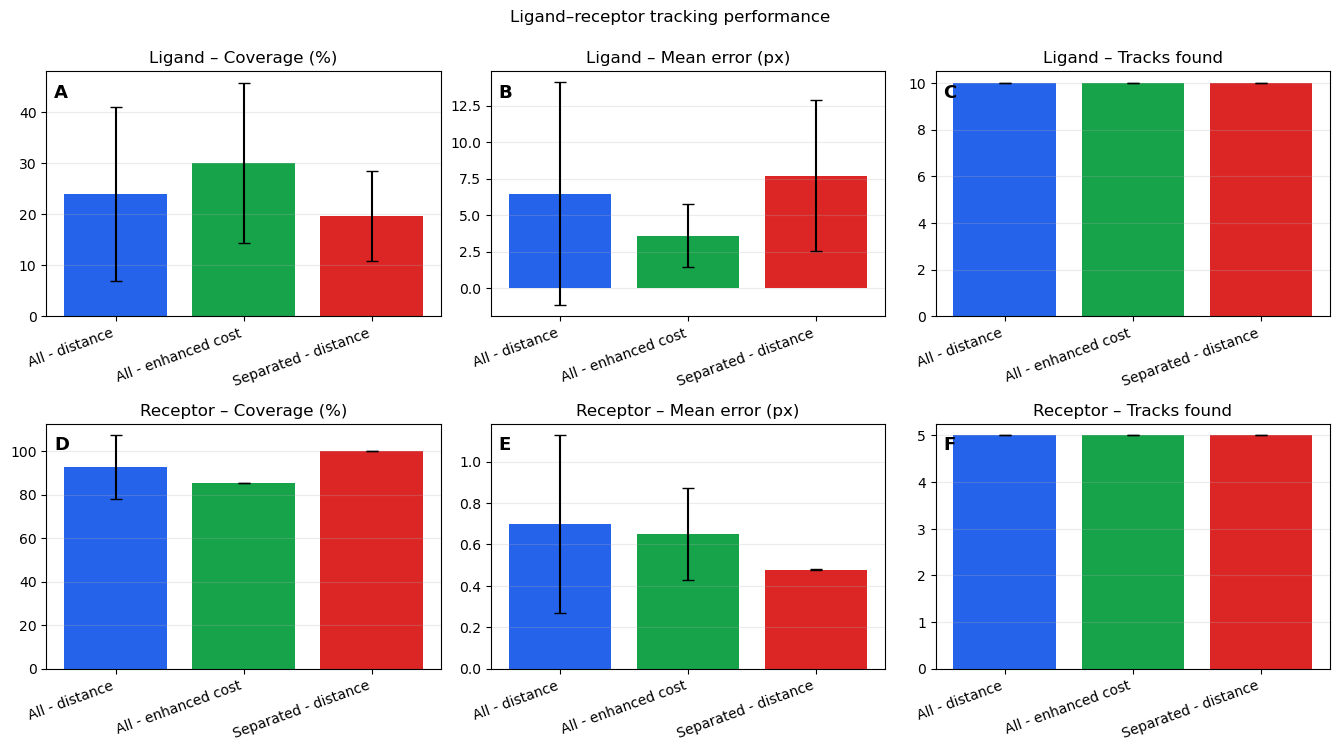

Saved ligand-receptor figure to C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Experiments\AllvsCostvsSep_ligand_receptor_summary.png


In [7]:
fig = plot_ligand_receptor_summary(lr_summary_df)
plt.show()
print(f"Saved ligand-receptor figure to {LR_FIGURE_PATH}")